# E-Commerce Sales Analysis

This dataset consists of orders made in different countries from December 2010 to December 2011. The company is a UK-based online retailer that mainly sells unique all-occasion gifts, with many of its customers being wholesalers.

In [7]:
suppressPackageStartupMessages(library(tidyverse))
retail = read_csv('data/online_retail.csv.gz', show_col_types = FALSE)
nrow(retail)
head(retail, n = 100)

[1] 541909

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850,United Kingdom
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850,United Kingdom
536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850,United Kingdom
536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850,United Kingdom


## Data Dictionary

| Variable |	Explanation |
|-----|------|
| InvoiceNo	| A 6-digit integral number uniquely assigned to each transaction. If this code starts with letter 'c' it indicates a cancellation. |
| StockCode	| A 5-digit integral number uniquely assigned to each distinct product. |
| Description |	Product (item) name |
| Quantity | The quantities of each product (item) per transaction |
| InvoiceDate |	The day and time when each transaction was generated |
| UnitPrice	| Product price per unit in sterling (pound) | 
| CustomerID | A 5-digit integral number uniquely assigned to each customer |
| Country	| The name of the country where each customer resides |

[Source](https://archive.ics.uci.edu/ml/datasets/online+retail#)  of dataset.

**Citation:** Daqing Chen, Sai Liang Sain, and Kun Guo, Data mining for the online retail industry: A case study of RFM model-based customer segmentation using data mining, Journal of Database Marketing and Customer Strategy Management, Vol. 19, No. 3, pp. 197-208, 2012 (Published online before print: 27 August 2012. doi: 10.1057/dbm.2012.17).


## Data Exploration


In [8]:
-- Explore the data in the table, overriding InvoiceDate as VARCHAR to avoid conversion errors
SELECT *
FROM read_csv_auto('online_retail.csv', types={'InvoiceDate': 'VARCHAR'})

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850,United Kingdom
536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850,United Kingdom
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850,United Kingdom
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850,United Kingdom
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850,United Kingdom
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850,United Kingdom
536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/10 8:26,4.25,17850,United Kingdom
536366,22633,HAND WARMER UNION JACK,6,12/1/10 8:28,1.85,17850,United Kingdom
536366,22632,HAND WARMER RED POLKA DOT,6,12/1/10 8:28,1.85,17850,United Kingdom


In [9]:
# Get the structure of the data
str(retail)

# Summary statistics for each column
summary(retail)

# Check for missing values in each column
colSums(is.na(retail))

spc_tbl_ [541,909 × 8] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ InvoiceNo  : chr [1:541909] "536365" "536365" "536365" "536365" ...
 $ StockCode  : chr [1:541909] "85123A" "71053" "84406B" "84029G" ...
 $ Description: chr [1:541909] "WHITE HANGING HEART T-LIGHT HOLDER" "WHITE METAL LANTERN" "CREAM CUPID HEARTS COAT HANGER" "KNITTED UNION FLAG HOT WATER BOTTLE" ...
 $ Quantity   : num [1:541909] 6 6 8 6 6 2 6 6 6 32 ...
 $ InvoiceDate: chr [1:541909] "12/1/10 8:26" "12/1/10 8:26" "12/1/10 8:26" "12/1/10 8:26" ...
 $ UnitPrice  : num [1:541909] 2.55 3.39 2.75 3.39 3.39 7.65 4.25 1.85 1.85 1.69 ...
 $ CustomerID : num [1:541909] 17850 17850 17850 17850 17850 ...
 $ Country    : chr [1:541909] "United Kingdom" "United Kingdom" "United Kingdom" "United Kingdom" ...
 - attr(*, "spec")=
  .. cols(
  ..   InvoiceNo = col_character(),
  ..   StockCode = col_character(),
  ..   Description = col_character(),
  ..   Quantity = col_double(),
  ..   InvoiceDate = col_character(),
  ..   UnitPrice

  InvoiceNo          StockCode         Description           Quantity        
 Length:541909      Length:541909      Length:541909      Min.   :-80995.00  
 Class :character   Class :character   Class :character   1st Qu.:     1.00  
 Mode  :character   Mode  :character   Mode  :character   Median :     3.00  
                                                          Mean   :     9.55  
                                                          3rd Qu.:    10.00  
                                                          Max.   : 80995.00  
                                                                             
 InvoiceDate          UnitPrice           CustomerID       Country         
 Length:541909      Min.   :-11062.06   Min.   :12346    Length:541909     
 Class :character   1st Qu.:     1.25   1st Qu.:13953    Class :character  
 Mode  :character   Median :     2.08   Median :15152    Mode  :character  
                    Mean   :     4.61   Mean   :15288                   

InvoiceNo   StockCode Description    Quantity InvoiceDate   UnitPrice 
          0           0        1454           0           0           0 
 CustomerID     Country 
     135080           0

## Data Analysis


### Return by Products
Looking at the variable summary, there are negative values in the Quantity and UnitPrice variables. Those in UnitPrice were described as existing bad debts. For negative Quantity values, they could be known as returned/cancelled transactions with positive UnitPrice and InvoiceNo starting with "C". The rest would be error transactions.
The one with the highest number of products returned was PAPER CRAFT, LITTLE BIRDIE, with approximately 81,000 items. Ranked second is MEDIUM CERAMIC TOP STORAGE JAR, which has nearly 75,000 items returned (74,215 of which were in one transaction). 
However, both products were returned in such large quantities in a single transaction by one customer. The returns may have been due to an error or mistake and requires further investigation with additional information, suggesting these are likely data anomalies or bulk order cancellations rather than typical customer return behaviour or repeated customer dissatisfaction.


REGENCY CAKESTAND 3 TIER records the highest number of returns (181), excluding Manual-entry and Postage returns, which have been categorised separately. This indicates a need for further investigation into product quality, customer expectations, or product handling.


In [10]:
# Load necessary libraries
library(dplyr)

# Identify debt and returned transactions
retail = retail %>%
  mutate(
    is_debt = if_else(UnitPrice < 0, "Yes", "No"),
    is_returned = if_else(Quantity < 0 & str_starts(InvoiceNo, "C"), "Yes", "No")
  )

# Extract Date from InvoiceDate
retail = retail %>%
  mutate(
    date = as.Date(InvoiceDate, "%m/%d/%y"),
    week = floor_date(date, "week"),
    month = floor_date(date, "month"),
    quarter = floor_date(date, "quarter")
	)

head(retail)

# Find out what products have the largest quantity returned and the highest returns
returns_quan <- retail %>%
  filter(is_returned == "Yes") %>%
  summarise(sum_quantity = sum(Quantity),
			.by = c(Description)) %>%
  arrange(sum_quantity)
head(returns_quan,10)

returns <- retail %>%
  summarise(count_return = sum(is_returned == "Yes"),
			.by = c(Description)) %>%
  arrange(desc(count_return))
head(returns,10)

InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,is_debt,is_returned,date,week,month,quarter
<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<date>,<date>,<date>,<date>
536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850,United Kingdom,No,No,2010-12-01,2010-11-28,2010-12-01,2010-10-01
536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850,United Kingdom,No,No,2010-12-01,2010-11-28,2010-12-01,2010-10-01
536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850,United Kingdom,No,No,2010-12-01,2010-11-28,2010-12-01,2010-10-01
536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850,United Kingdom,No,No,2010-12-01,2010-11-28,2010-12-01,2010-10-01
536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850,United Kingdom,No,No,2010-12-01,2010-11-28,2010-12-01,2010-10-01
536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/10 8:26,7.65,17850,United Kingdom,No,No,2010-12-01,2010-11-28,2010-12-01,2010-10-01


Description,sum_quantity
<chr>,<dbl>
"PAPER CRAFT , LITTLE BIRDIE",-80995
MEDIUM CERAMIC TOP STORAGE JAR,-74494
ROTATING SILVER ANGELS T-LIGHT HLDR,-9376
Manual,-4066
FAIRY CAKE FLANNEL ASSORTED COLOUR,-3150
PINK BLUE FELT CRAFT TRINKET BOX,-2617
WHITE HANGING HEART T-LIGHT HOLDER,-2578
GIN + TONIC DIET METAL SIGN,-2030
HERB MARKER BASIL,-1527


Description,count_return
<chr>,<int>
Manual,244
REGENCY CAKESTAND 3 TIER,181
POSTAGE,126
JAM MAKING SET WITH JARS,87
Discount,77
SET OF 3 CAKE TINS PANTRY DESIGN,74
SAMPLES,61
STRAWBERRY CERAMIC TRINKET BOX,55
ROSES REGENCY TEACUP AND SAUCER,54


### Business Growth and Market Dynamics
The two bulk transactions were considered anomalies; they would be removed to avoid any effect on further analysis. Special transaction codes such as postage, discounts, and manual adjustments were excluded to ensure that the analysis reflected actual product performance and customer behaviour.

#### Revenue Growth
Revenue shows a growing tendency in the second half of the year, likely driven by seasonal demand due to the holiday season, especially in the last quarter of both years. However, a sharp decline witnessed in December 2011 may indicate a post-peak demand drop. 
Weekly revenue fluctuations suggest unstable purchasing patterns, possibly driven by bulk orders, promotions, or irregular customer behaviour, particularly during off-peak seasons around the first and second quarters of the year.
While the business is growing notably, returns are increasingly offsetting revenue gains due to the widening gap between gross and net revenue in the quarterly view. Return rate is the key driver of reducing net revenue despite growth over time. This indicates the growth does not fully translate to profitability, highlighting the importance of focusing on return management.

[1] 538994

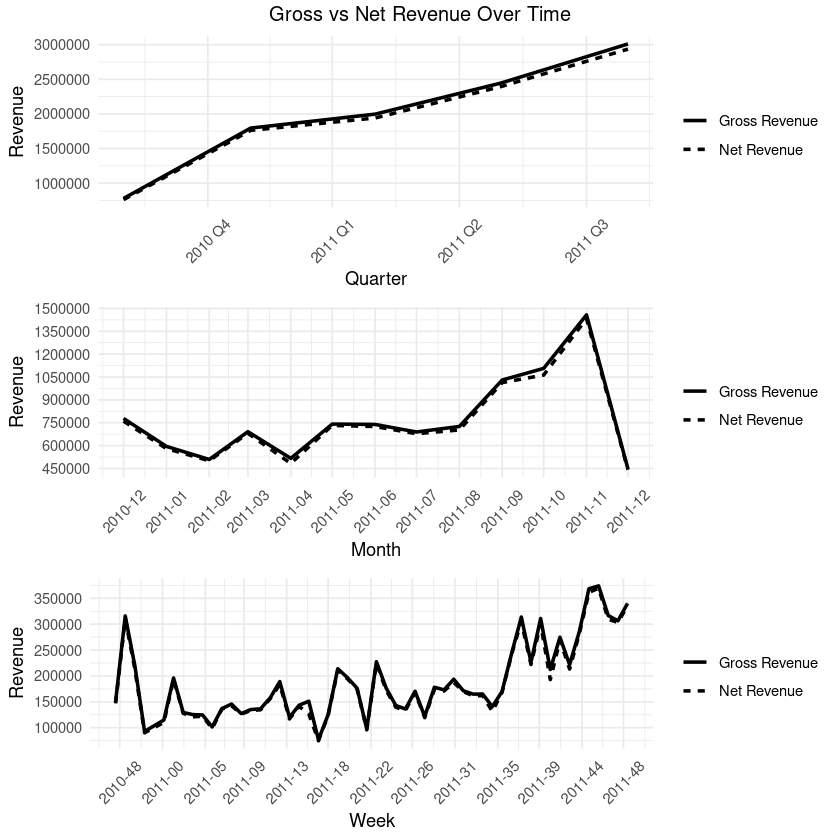

In [11]:
library(ggplot2)
retail2 = retail %>% 
filter (!Quantity %in% c("80995","74215","-80995","-74215"),is_debt == "No",
    	!StockCode %in% c("AMAZONFEE","B","BANK CHARGES","C2","CRUK",
                      "D","DOT","M","POST","S")) %>% 
mutate (revenue = Quantity * UnitPrice) 

nrow(retail2)

# Revenue over time
## Over quarters
rev_quarter <- retail2 %>% summarise(
    gross_revenue = sum(revenue[is_returned == "No"]),
    net_revenue = sum(revenue),
    .by = quarter)

r1 <- ggplot(rev_quarter, aes(x = quarter)) +
  geom_line(aes(y = gross_revenue, linetype = "Gross Revenue"), linewidth = 1) +
  geom_line(aes(y = net_revenue, linetype = "Net Revenue"), linewidth = 1) +	
  scale_x_date(date_breaks = "3 months", labels = function(x) paste0(year(x), " Q", quarter(x))) +
  labs(
    x = "Quarter",
    y = "Revenue",
    linetype = ""
  ) +
  theme_minimal() + 
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

## Over months
rev_month <- retail2 %>% summarise(
    gross_revenue = sum(revenue[is_returned == "No"]),
    net_revenue = sum(revenue),
    .by = month)
			   
r2 <- ggplot(rev_month, aes(x = month)) +
  geom_line(aes(y = gross_revenue, linetype = "Gross Revenue"), linewidth = 1) +
  geom_line(aes(y = net_revenue, linetype = "Net Revenue"), linewidth = 1) +	
  scale_y_continuous(breaks = seq(0,1500000, by = 150000)) +
  scale_x_date(date_labels = "%Y-%m", breaks = "1 month") +
  labs(
    x = "Month",
    y = "Revenue",
    linetype = ""
  ) +
  theme_minimal() + 
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

## Over weeks
rev_week <- retail2 %>% summarise(
    gross_revenue = sum(revenue[is_returned == "No"]),
    net_revenue = sum(revenue),
    .by = week)
			   
r3 <- ggplot(rev_week, aes(x = week)) +
  geom_line(aes(y = gross_revenue, linetype = "Gross Revenue"), linewidth = 1) +
  geom_line(aes(y = net_revenue, linetype = "Net Revenue"), linewidth = 1) +	
  scale_y_continuous(breaks = seq(100000,380000, by = 50000)) +
  scale_x_date(date_labels = "%Y-%U", date_breaks = "1 month") +
  labs(
    x = "Week",
    y = "Revenue",
    linetype = ""
  ) +
  theme_minimal() + 
  theme(axis.text.x = element_text(angle = 45, vjust = 0.5))

## Combine graphs
library("gridExtra")
grid.arrange(r1, r2, r3, ncol = 1, nrow = 3,
			top = "Gross vs Net Revenue Over Time")
			   


#### UK vs International Markets
As the business is UK-based, the UK remains the core market while dominating other countries in both volume and revenue, with a moderate average order value (around £425 per order) and a smaller order basket (approximately 218 items per order). Even though international markets contribute relatively lower total orders, they exhibit significantly higher values and much larger basket sizes. 

The data shows the UK as a high-volume, low-value market, with more frequent and small-size purchases, while non-UK customers behave quite the opposite, with less frequent, large-volume or wholesale-like purchasing behaviour, possibly due to difficulties that may be encountered when buying/shipping from abroad (time, cost, inventory, etc.). This suggests a need for necessary strategies in terms of pricing, inventory, and logistics management.

#### Return Behaviour
Some countries show relatively low order volume, which might cause small sample bias and be misleading when interpreting the figures. Therefore, a minimum threshold of 20 has been applied to ensure statistical reliability when calculating return rates.

Return patterns were seen to be strongly market-dependent and vary notably across markets. Italy, Switzerland and Germany are the top three with the highest return rates (40%, 36%, and 30%, respectively). These high-return European markets exhibit potential issues in product fit or customer expectations. 

In contrast, the Netherlands stands out with the lowest return rate (~3%), suggesting alignments between supply - product offering and demand - customer expectations. The UK has a moderate return rate (~15%) and stable purchasing behaviour, making it a reliable benchmark for performance evaluations.

#### Market Segmentation: Value vs Risk
Markets can be segmented based on profitability potential and operational risk, as explicitly witnessed by the market performance. The Netherlands emerges as a high-value, low-risk market, characterised by the highest average order value, the largest basket size, and the lowest return rates. These factors make the Netherlands a high-performing market and an ideal profile for profitability and growing potential. 

Conversely, when combining similar factors, Sweden, Switzerland and EIRE show higher risk profiles with larger order sizes, higher order values, and much higher return rates, amplifying the adverse financial impact on the business.

In [12]:
# Total returns and revenue by country
by_country <- retail2 %>%
  summarise(
	total_purchase = n_distinct(InvoiceNo[is_returned == "No"]),
	total_return = n_distinct(InvoiceNo[is_returned == "Yes"]),
    return_rate = ifelse(total_purchase < 20, NA_real_, round(total_return / total_purchase * 100, 2)),
    total_revenue = sum(revenue, na.rm = TRUE),
	avg_ordervalue = round(sum(revenue[is_returned == "No"]) / total_purchase,2),
	avg_qty = round(sum(Quantity[is_returned == "No"]) / total_purchase,2),
    .by = Country
  ) %>%
  arrange(desc(return_rate))

head(by_country,38)


Country,total_purchase,total_return,return_rate,total_revenue,avg_ordervalue,avg_qty
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Italy,35,14,40.00,15276.34,452.01,230.49
Switzerland,50,18,36.00,52505.35,1061.76,610.56
Germany,443,135,30.47,200808.40,464.04,266.68
Channel Islands,25,6,24.00,19936.29,800.30,379.48
Sweden,34,8,23.53,35176.91,1083.51,1060.06
EIRE,282,65,23.05,259663.46,961.58,522.47
Australia,56,11,19.64,136990.00,2467.34,1503.71
Belgium,98,19,19.39,36662.96,376.81,234.31
France,382,59,15.45,182163.39,483.20,291.28


## Conclusions
### Key Insights
#### Business Growth and Profitability
The business demonstrates a clear upward revenue trend, particularly in peak seasonal periods. However, returns are an existing obstacle pressing profitability in specific markets and large-volume orders. The small number of large-volume transactions takes up a disproportionately high share of returns, amplifying financial risk due to the uneven scale effect. The growth is increasingly offset by rising returns, which becomes the key factor limiting margin expansion.

#### Localised Nature of Returns
Returns are not evenly distributed across the business but are concentrated in specific markets and products, indicating that the problem is operationally localised, not systemic. This creates an opportunity for targeted interventions instead of general, one-size-fits-all solutions.  

#### Market-level Segmentation: Value vs Risk
There are apparent structural differences existing across markets. The UK remains a stable revenue foundation, supported by its high transaction volume and relatively consistent performance, which should be maintained and optimised as the core market.
At the same time, international markets present a more complex picture. While they offer strong revenue potential due to higher order values and bulk purchasing behaviour contributing to higher revenue potential, they also carry considerably higher risks, driven by elevated return rates and large order sizes. This means that high-value bulk purchasing can act as a double-edged sword, providing business opportunities for revenue growth and financial threats when returns occur. 
Across the international markets, the Netherlands emerges as a high-value, low-risk market, combining strong revenue contribution with minimal return rates. Meanwhile, markets such as Switzerland contrastingly exhibit high return rates alongside large order sizes, indicating high-risk, high-volatility profiles.

#### Churn Risk Analysis
Although returns do not directly translate into churn, the return behaviour could be used as a proxy indicator measuring customer dissatisfaction and potential churn risk. High-return or high-risk markets could demonstrate potential churn risk due to expectation or operational mismatches. In the meantime, the UK and the Netherlands indicate a much more stable picture in purchasing and return patterns, suggesting stronger customer retention and lower churn likelihood, given the fact that the UK remains the core market.

### Strategic Recommendations
#### Market-focused Growth
For more sustainable growth, balanced, operationally focused and differentiated market strategies should be adopted. The business should continue to prioritise scaling high-performing regions (high-value, low-return), like the Netherlands, while applying more targeted approaches to high-risk markets (large basket sizes and rising return rates such as Switzerland). This includes closely monitoring bulk orders, identifying and implementing strict quality control for high-return products, and applying tailored logistics management moves to improve customer experience as well as reduce damages, delays, or mismatches that could drive returns to manage volatility.
For the core, stable market (the UK), the business should continue to maintain and optimise current strategies to enhance this stability.

#### Return Reduction
Reducing return rates should be the first business priority, as they fundamentally impact both profitability and long-term customer retention. This requires refining product quality, improving fulfilment accuracy and clarity of product information, developing comprehensive solutions for problems customers might encounter during actual product delivery and post-purchase processes to enhance customer experience, and strengthening cross-border logistics procedures, as most of the returns are international. 
By addressing these issues, the business can simultaneously protect the margins, grow into middle- to high-value segments, and reduce potential churn risk as well as strengthen retention.

#### Bulk Transaction Control
Since a small number of large-volume transactions account for disproportionately to overall returns, the business should implement stricter monitoring and control mechanisms for bulk orders. This entails early detection of high-risk transaction patterns, validation checks, and the implementation of safeguards to reduce possible financial exposure from large-scale returns.

